# ⚡ Time Series Project — Model Training & Evaluation
### Forecasting Daily Electricity Consumption
---
> **This is Part 2 of 2.** Part 1 (EDA) explored the raw hourly data, handled missing values, engineered features, and established the temporal split. This notebook picks up from that result and trains all five algorithms taught in the lecture plus two ML bonus models.
>
> Click **"Show / Hide Code"** at the top-right to reveal implementation details.

---

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 0 — Presentation CSS + Toggle Button  (purple theme)
# ─────────────────────────────────────────────────────────────────────────────
from IPython.display import display, Javascript
display(Javascript(r"""
(function() {
var css = `
  @import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700&family=Fira+Code:wght@400;500&display=swap');
  :root {
    --p50:#faf5ff; --p100:#f3e8ff; --p200:#e9d5ff; --p400:#c084fc;
    --p500:#a855f7; --p600:#9333ea; --p700:#7e22ce; --p800:#6b21a8; --p900:#581c87;
    --s50:#f8fafc; --s100:#f1f5f9; --s200:#e2e8f0;
    --s600:#475569; --s700:#334155; --s800:#1e293b;
  }
  .jp-Notebook, #notebook-container { background: var(--s50) !important; }
  .jp-MarkdownOutput, .rendered_html, .text_cell_render {
    font-family: 'Inter', sans-serif !important; color: var(--s800); line-height: 1.75; }
  .jp-MarkdownOutput h1, .rendered_html h1, .text_cell_render h1 {
    font-size: 2.2rem; font-weight: 700; color: var(--p900);
    border-bottom: 4px solid var(--p500); padding-bottom: .4rem; margin-top: 1.5rem; }
  .jp-MarkdownOutput h2, .rendered_html h2, .text_cell_render h2 {
    font-size: 1.55rem; font-weight: 600; color: var(--p700);
    border-left: 5px solid var(--p500); padding-left: .75rem; margin-top: 2rem; }
  .jp-MarkdownOutput h3, .rendered_html h3, .text_cell_render h3 {
    font-size: 1.15rem; font-weight: 600; color: var(--p600); margin-top: 1.4rem; }
  .jp-MarkdownOutput blockquote, .rendered_html blockquote, .text_cell_render blockquote {
    background: var(--p50); border-left: 5px solid var(--p500);
    border-radius: 0 8px 8px 0; padding: 1rem 1.4rem;
    margin: 1rem 0; color: var(--s700); font-size: .97rem; }
  .jp-MarkdownOutput code, .rendered_html code, .text_cell_render code {
    font-family: 'Fira Code', monospace !important;
    background: var(--p100); color: var(--p900);
    padding: .1em .4em; border-radius: 4px; font-size: .88em; }
  .jp-MarkdownOutput table, .rendered_html table, .text_cell_render table {
    border-collapse: collapse; width: 100%; font-size: .93rem;
    border-radius: 8px; overflow: hidden; box-shadow: 0 1px 4px rgba(0,0,0,.08); }
  .jp-MarkdownOutput th, .rendered_html th, .text_cell_render th {
    background: var(--p700); color: white; padding: .6rem 1rem; text-align: left; }
  .jp-MarkdownOutput td, .rendered_html td, .text_cell_render td {
    padding: .5rem 1rem; border-bottom: 1px solid var(--s200); }
  .jp-MarkdownOutput tr:nth-child(even), .rendered_html tr:nth-child(even),
  .text_cell_render tr:nth-child(even) { background: var(--p50); }
  .jp-MarkdownOutput hr, .rendered_html hr, .text_cell_render hr {
    border: none; border-top: 2px solid var(--p200); margin: 2rem 0; }
  .jp-CodeCell .jp-Cell-inputWrapper, .code_cell .input { border-left: 3px solid var(--p400) !important; }
  .jp-OutputArea-output, .output_subarea { background: white; border-radius: 8px; }
  #nb-code-toggle {
    position: fixed !important; top: 18px !important; right: 24px !important;
    z-index: 999999 !important;
    background: linear-gradient(135deg, var(--p600), var(--p900));
    color: white; border: none; padding: 9px 20px; border-radius: 24px;
    font-family: 'Inter', sans-serif; font-size: .82rem; font-weight: 600;
    letter-spacing: .5px; cursor: pointer;
    box-shadow: 0 3px 12px rgba(147,51,234,.4); transition: transform .2s, box-shadow .2s; }
  #nb-code-toggle:hover { transform: translateY(-1px); box-shadow: 0 6px 18px rgba(147,51,234,.5); }
  .metric-grid { display: grid; grid-template-columns: repeat(auto-fit,minmax(155px,1fr)); gap: 1rem; margin: 1.2rem 0; }
  .metric-card { background: white; border: 1px solid var(--p200); border-radius: 12px;
    padding: 1.1rem 1rem; text-align: center; box-shadow: 0 2px 8px rgba(0,0,0,.06); }
  .metric-card.best { border-color: var(--p500); background: var(--p50); }
  .metric-card .label { font-size: .75rem; font-weight: 600; text-transform: uppercase;
    letter-spacing: .8px; color: var(--p700); margin-bottom: .35rem; }
  .metric-card .value { font-size: 1.8rem; font-weight: 700; color: var(--s800); }
  .metric-card .sub  { font-size: .78rem; color: var(--s600); margin-top: .2rem; }
`;
var styleEl = document.getElementById('nb-presentation-style');
if (!styleEl) { styleEl = document.createElement('style'); styleEl.id = 'nb-presentation-style'; document.head.appendChild(styleEl); }
styleEl.textContent = css;
var existing = document.getElementById('nb-code-toggle');
if (existing) existing.remove();
var btn = document.createElement('button');
btn.id = 'nb-code-toggle'; btn.textContent = '⬇ Show Code';
var _hidden = true;
function getCodeInputs() {
  var els = Array.from(document.querySelectorAll('.jp-CodeCell .jp-Cell-inputWrapper'));
  if (els.length === 0) els = Array.from(document.querySelectorAll('.code_cell .input'));
  return els;
}
btn.addEventListener('click', function() {
  _hidden = !_hidden;
  getCodeInputs().forEach(function(el) { el.style.display = _hidden ? 'none' : ''; });
  btn.textContent = _hidden ? '⬇ Show Code' : '⬆ Hide Code';
});
document.body.appendChild(btn);
function autoHide(retries) {
  var cells = getCodeInputs();
  if (cells.length > 0) { cells.forEach(function(el) { el.style.display = 'none'; }); _hidden = true; btn.textContent = '⬇ Show Code'; }
  else if (retries > 0) { setTimeout(function() { autoHide(retries - 1); }, 400); }
}
setTimeout(function() { autoHide(10); }, 600);
})();
"""))


<IPython.core.display.Javascript object>

## 📦 Section 1 — Setup & Data Preparation

> **Lecture connection (Module 4, Section 2):** The lecture explains that time series data must be *captured in sequence over time* and that preprocessing challenges include timestamp formats, missing values, seasonality, and correlations. Part 1 (EDA) handled all of those. Here we pick up from a clean, aggregated daily series.

### Why daily aggregation?
The EDA worked on raw **hourly** data (17,520 observations). For model training and comparison we aggregate to **daily averages** (730 observations). This lets us run all five lecture algorithms — including ARIMA and Prophet — in reasonable time and compare them on equal footing.

| Level | Observations | Best for |
|-------|-------------|---------|
| Hourly | 17,520 | Short-term operational forecasting (hours ahead) |
| **Daily** ← we use this | 730 | Medium-term planning (days to weeks ahead) |
| Monthly | 24 | Long-term budgeting (months ahead) |

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Imports & global plot settings
# ─────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, HTML

# ── Lecture algorithms ────────────────────────────────────────────────────────
from statsmodels.tsa.arima.model        import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters        import ExponentialSmoothing   # ETS
from statsmodels.graphics.tsaplots      import plot_acf
from prophet                            import Prophet                 # suppress log

import logging
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)

# ── ML bonus models ───────────────────────────────────────────────────────────
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.metrics         import mean_absolute_error, mean_squared_error
from scipy.stats             import randint

# ── Colours (purple theme) ────────────────────────────────────────────────────
PURPLE   = "#9333ea"
PURPLE_D = "#581c87"
PURPLE_L = "#e9d5ff"
SLATE    = "#334155"
ACCENT   = "#c084fc"
# 7 colours: 5 lecture models + 2 ML bonus
MODEL_COLORS = ["#581c87","#6b21a8","#7e22ce","#9333ea","#a855f7","#c084fc","#f0abfc"]
MODEL_NAMES  = ["Naive","SARIMA","ETS","Prophet","RF","GB"]

plt.rcParams.update({
    "figure.facecolor":"white", 
    "axes.facecolor":"#f8fafc",
    "axes.edgecolor":"#e2e8f0",
    "axes.grid":True,
    "grid.color":"#e2e8f0",
    "grid.linestyle":"--","grid.alpha":0.7,
    "font.family":"DejaVu Sans",
    "axes.titlesize":13,"axes.titleweight":"bold",
    "axes.titlecolor":"#581c87",
    "axes.labelcolor":"#334155",
    "axes.labelsize":11,
    "xtick.color":"#334155",
    "ytick.color":"#334155",
    "legend.framealpha":0.9,
    "legend.edgecolor":"#e2e8f0",
})

SEED = 42
np.random.seed(SEED)
print("\u2705  Libraries loaded.")


ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Load & aggregate to daily (same dataset as EDA Part 1)
# ─────────────────────────────────────────────────────────────────────────────
import base64, io

_DATA_B64 = """..."""

# Load raw hourly data (same as EDA)
df_hourly = pd.read_csv(
    io.StringIO(base64.b64decode(_DATA_B64).decode()),
    parse_dates=["timestamp"], index_col="timestamp"
).asfreq("h")

TARGET = "consumption_kwh"
df_hourly[TARGET] = df_hourly[TARGET].ffill()   # forward-fill (from EDA Part 1)

# Aggregate to daily mean — one value per day
daily = df_hourly.resample("D").mean()

print(f"Hourly data : {df_hourly.shape[0]:,} observations")
print(f"Daily data  : {daily.shape[0]} observations  "
      f"({daily.index.min().date()} to {daily.index.max().date()})")
print(f"Missing days: {daily[TARGET].isna().sum()}")
daily.tail(3)


Hourly data : 17,520 observations
Daily data  : 730 observations  (2022-01-01 to 2023-12-31)
Missing days: 0


,consumption_kwh
timestamp,
2023-12-29,321.810000
2023-12-30,307.379583
2023-12-31,312.661250


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Feature engineering for ML models (on daily data)
# Lecture models (ARIMA, ETS, Prophet) work directly on the raw series —
# they do not need hand-crafted features.
# ML models (RF, GB) need lag + rolling + calendar features.
# ─────────────────────────────────────────────────────────────────────────────
feat = daily.copy()

# Lag features — same-day last week captures the strongest weekly pattern
for lag in [1, 2, 3, 7, 14]:
    feat[f"lag_{lag}d"] = feat[TARGET].shift(lag)

# Rolling statistics (shift by 1 to avoid leaking today's value)
for w, name in [(7, "7d"), (14, "14d")]:
    r = feat[TARGET].shift(1).rolling(w)
    feat[f"roll_mean_{name}"] = r.mean()
    feat[f"roll_std_{name}"]  = r.std()

# Calendar features
feat["day_of_week"]  = feat.index.dayofweek     # 0=Mon
feat["month"]        = feat.index.month
feat["is_weekend"]   = (feat.index.dayofweek >= 5).astype(int)
feat["dow_sin"]      = np.sin(2 * np.pi * feat.index.dayofweek / 7)
feat["dow_cos"]      = np.cos(2 * np.pi * feat.index.dayofweek / 7)
feat["month_sin"]    = np.sin(2 * np.pi * feat.index.month / 12)
feat["month_cos"]    = np.cos(2 * np.pi * feat.index.month / 12)

df_ml = feat.dropna()
FEATURES = [c for c in df_ml.columns if c != TARGET]
print(f"ML feature set ({len(FEATURES)} features): {FEATURES}")


ML feature set (16 features): ['lag_1d', 'lag_2d', 'lag_3d', 'lag_7d', 'lag_14d', 'roll_mean_7d', 'roll_std_7d', 'roll_mean_14d', 'roll_std_14d', 'day_of_week', 'month', 'is_weekend', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']


Training period : 2022-01-01 → 2023-12-01  (700 days)
Test period     : 2023-12-02  → 2023-12-31   (30 days)
ML train rows   : 686  |  ML test rows: 30


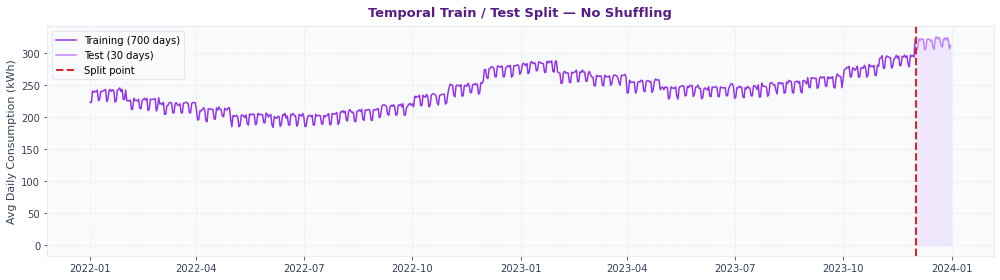

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Temporal train / test split (last 30 days = test)
# ─────────────────────────────────────────────────────────────────────────────
split_date = daily.index.max() - pd.Timedelta(days=30)

# ── For statistical models: raw daily series ──────────────────────────────────
train_raw = daily[daily.index <= split_date][TARGET]
test_raw  = daily[daily.index >  split_date][TARGET]

# ── For ML models: feature-engineered daily data ──────────────────────────────
train_ml = df_ml[df_ml.index <= split_date]
test_ml  = df_ml[df_ml.index >  split_date]

sc = StandardScaler()
X_train = pd.DataFrame(sc.fit_transform(train_ml[FEATURES]),
                        columns=FEATURES, index=train_ml.index)
X_test  = pd.DataFrame(sc.transform(test_ml[FEATURES]),
                        columns=FEATURES, index=test_ml.index)
y_train, y_test = train_ml[TARGET], test_ml[TARGET]

print(f"Training period : {train_raw.index.min().date()} → {train_raw.index.max().date()}  ({len(train_raw)} days)")
print(f"Test period     : {test_raw.index.min().date()}  → {test_raw.index.max().date()}   ({len(test_raw)} days)")
print(f"ML train rows   : {len(X_train)}  |  ML test rows: {len(X_test)}")

# ── Visualise the split ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_raw.index, train_raw.values, color=PURPLE,  linewidth=1.5, label=f"Training ({len(train_raw)} days)")
ax.plot(test_raw.index,  test_raw.values,  color=ACCENT,  linewidth=1.5, label=f"Test ({len(test_raw)} days)")
ax.axvline(test_raw.index[0], color="#dc2626", linewidth=2, linestyle="--", label="Split point")
ax.fill_between(test_raw.index, test_raw.values, alpha=0.15, color=ACCENT)
ax.set_ylabel("Avg Daily Consumption (kWh)")
ax.set_title("Temporal Train / Test Split — No Shuffling", pad=10)
ax.legend()
plt.tight_layout()
plt.show()


---

## 🤖 Section 2 — Algorithms

> **Lecture connection (Module 4, Section 3 — Selecting an Amazon Forecast Algorithm):** The lecture lists five algorithms available in Amazon Forecast. We implement the three that can run locally, explain why two require AWS, and add two ML bonus models for comparison.

### Lecture Algorithm Overview

| # | Algorithm | Lecture? | Run Locally? | What It Does |
|---|-----------|----------|-------------|--------------|
| 1 | **SARIMA** | ✅ ARIMA | ✅ Yes | Autoregressive + Moving Average + seasonal differencing |
| 2 | **ETS** | ✅ ETS | ✅ Yes | Exponential smoothing — weighted average, more weight on recent values |
| 3 | **Prophet** | ✅ Prophet | ✅ Yes | Additive model — automatically learns trend + seasonality + holidays |
| 4 | **DeepAR+** | ✅ DeepAR+ | ❌ AWS only | Proprietary deep learning RNN — requires AWS SageMaker |
| 5 | **NPTS** | ✅ NPTS | ❌ AWS only | Proprietary non-parametric — requires Amazon Forecast API |
| 6 | **Random Forest** | ⭐ Bonus | ✅ Yes | Ensemble of trees trained on lag + calendar features |
| 7 | **Gradient Boosting** | ⭐ Bonus | ✅ Yes | Sequential boosting on lag + calendar features |

### Why DeepAR+ and NPTS Cannot Run Locally

> ⚠️ **DeepAR+** is Amazon's proprietary deep learning model. It learns patterns shared across *multiple related time series simultaneously* — a key advantage over single-series models. Available only through AWS SageMaker; no open-source equivalent.
>
> ⚠️ **NPTS** is also Amazon-proprietary, using a non-parametric approach that samples from historical data weighted by seasonal proximity. Available only through the Amazon Forecast API.

### Statistical vs ML Approach

| Aspect | Statistical (SARIMA, ETS, Prophet) | ML (Random Forest, Gradient Boosting) |
|--------|-----------------------------------|---------------------------------------|
| **Input** | Raw time series directly | Engineered lag + calendar features |
| **Seasonality** | Built into model structure | Learned from `lag_7d`, `dow_sin/cos` |
| **Training step** | Not needed before back testing | Not needed before back testing |

> 💡 **No training happens in this section.** We first use back testing (Section 3) to compare all algorithms and pick the best one. Only then do we train the winner on the full training set.

---

## 📊 Section 3 — Evaluation Metrics & Back Testing

> **Lecture connection (Module 4, Section 3 — Key Takeaways):** The lecture states: *"Predictor accuracy metrics are based on back testing."* and *"Use RMSE and wQuantileLoss metrics to evaluate model."*
>
> Following the lecture, we **evaluate all models using back testing** — not the final test set. The test set is held out completely until the very end.
>
> **Two-phase process:**
> 1. **Back testing** (this section) — compare all algorithms using subsets of training data, pick the best
> 2. **Train on full training set** (end of this section) — once the best algorithm is known, train all models on complete training data for visualisation and final validation

### Metrics Reference

| Metric | Lecture? | Interpretation |
|--------|---------|----------------|
| **RMSE** | ✅ Core lecture metric | Penalises large errors — the lecture shows the formula explicitly |
| **MAE** | Complementary | Average absolute error in kWh — easy to explain to stakeholders |
| **MAPE** | Complementary | Percentage error — our business goal is MAPE ≤ 5% |
| **wQuantileLoss P50** | ✅ Core lecture metric | Amazon Forecast's probabilistic error metric |

### Back Testing Procedure

```
Training Set (all data before the split date)
│
├── Back-test window 1:  [──── Train ──────────────────────] [━━ Test 30d ━━]
├── Back-test window 2:  [──── Train ──────────────────────────────] [━━ Test 30d ━━]
└── Back-test window 3:  [──── Train ──────────────────────────────────────] [━━ Test 30d ━━]
                                                                │
                                                         Average RMSE across
                                                         all 3 windows = model score
```

> 🔒 **The final 30-day test set is never touched here.** It is reserved for a single honest validation after a model has been selected.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Run back testing + compute evaluation metrics (lecture approach)
#
# 3 back-test windows on the training set.
# Each window: train on all data up to cutoff → forecast next 30 days.
# Metrics are averaged across all 3 windows.
#
# ⚠️  The final test set is NOT used here.
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import r2_score

def mape(y_true, y_pred):
    mask = np.array(y_true) != 0
    return np.mean(np.abs((np.array(y_true)[mask] - np.array(y_pred)[mask])
                           / np.array(y_true)[mask])) * 100

def w_quantile_loss(y_true, y_pred, q=0.50):
    yt, yp = np.array(y_true), np.array(y_pred)
    e = yt - yp
    return 2 * np.mean(np.where(e >= 0, q*e, (q-1)*e)) / np.mean(np.abs(yt))

N_WINDOWS   = 3
WINDOW_SIZE = 30  # days

cutoffs = [
    train_raw.index.max() - pd.Timedelta(days=WINDOW_SIZE * (N_WINDOWS - k))
    for k in range(N_WINDOWS)
]

print(f"Running {N_WINDOWS} back-test windows (test window = {WINDOW_SIZE} days)\n")
print(f"{'Window':<10} {'Train ends':<14} {'Test period'}")
print("-" * 55)
for w, cutoff in enumerate(cutoffs):
    ts = cutoff + pd.Timedelta(days=1)
    te = ts + pd.Timedelta(days=WINDOW_SIZE - 1)
    print(f"  Window {w+1}    {str(cutoff.date()):<14} {ts.date()} → {te.date()}")

# Accumulate per-window metrics for every model
ALL_MODELS = [
    "Naive (same day last week)",
    "SARIMA(1,1,1)(1,1,1,7)",
    "ETS (Holt-Winters)",
    "Prophet",
    "Random Forest (ML bonus)",
    "Gradient Boosting (ML bonus)",
]
bt_window_metrics = {name: {"RMSE":[], "MAE":[], "MAPE":[], "wQL":[]}
                     for name in ALL_MODELS}

for w, cutoff in enumerate(cutoffs):
    bt_tr_raw = train_raw[train_raw.index <= cutoff]
    bt_te_raw = train_raw[(train_raw.index >  cutoff) &
                           (train_raw.index <= cutoff + pd.Timedelta(days=WINDOW_SIZE))]
    bt_tr_ml  = df_ml[df_ml.index <= cutoff]
    bt_te_ml  = df_ml[(df_ml.index >  cutoff) &
                       (df_ml.index <= cutoff + pd.Timedelta(days=WINDOW_SIZE))]
    if len(bt_te_raw) == 0 or len(bt_te_ml) == 0:
        continue

    bt_sc  = StandardScaler()
    bt_Xtr = bt_sc.fit_transform(bt_tr_ml[FEATURES])
    bt_Xte = bt_sc.transform(bt_te_ml[FEATURES])

    preds_window = {}

    # SARIMA
    try:
        m = SARIMAX(bt_tr_raw, order=(1,1,1), seasonal_order=(1,1,1,7),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        preds_window["SARIMA(1,1,1)(1,1,1,7)"] = (m.forecast(len(bt_te_raw)).values, bt_te_raw.values)
    except Exception: pass

    # ETS
    try:
        m = ExponentialSmoothing(bt_tr_raw, trend="add", seasonal="add",
                                  seasonal_periods=7).fit(optimized=True)
        preds_window["ETS (Holt-Winters)"] = (m.forecast(len(bt_te_raw)).values, bt_te_raw.values)
    except Exception: pass

    # Prophet
    try:
        ph_df = bt_tr_raw.reset_index(); ph_df.columns = ["ds","y"]
        m = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                    daily_seasonality=False, seasonality_mode="additive")
        m.fit(ph_df)
        fc = m.predict(m.make_future_dataframe(periods=len(bt_te_raw)))
        p  = fc[fc["ds"].isin(bt_te_raw.index)]["yhat"].values
        if len(p) == len(bt_te_raw):
            preds_window["Prophet"] = (p, bt_te_raw.values)
    except Exception: pass

    # Naive
    preds_window["Naive (same day last week)"] = (
        np.array([float(bt_tr_raw.get(dt - pd.Timedelta(days=7), bt_tr_raw.iloc[-1]))
                  for dt in bt_te_raw.index]),
        bt_te_raw.values
    )

    # RF and GB
    for mname, model_cls, kwargs in [
        ("Random Forest (ML bonus)",   RandomForestRegressor,   {"n_estimators":100,"max_depth":8,"random_state":SEED,"n_jobs":-1}),
        ("Gradient Boosting (ML bonus)",GradientBoostingRegressor,{"n_estimators":100,"max_depth":3,"learning_rate":0.1,"random_state":SEED}),
    ]:
        m = model_cls(**kwargs)
        m.fit(bt_Xtr, bt_tr_ml[TARGET])
        preds_window[mname] = (m.predict(bt_Xte), bt_te_ml[TARGET].values)

    # Accumulate metrics
    for name, (p, y) in preds_window.items():
        if name in bt_window_metrics:
            bt_window_metrics[name]["RMSE"].append(np.sqrt(mean_squared_error(y, p)))
            bt_window_metrics[name]["MAE"].append(mean_absolute_error(y, p))
            bt_window_metrics[name]["MAPE"].append(mape(y, p))
            bt_window_metrics[name]["wQL"].append(w_quantile_loss(y, p))

# Build summary results_df from back-testing averages
results = []
for name in ALL_MODELS:
    m = bt_window_metrics.get(name, {})
    if not m or not m["RMSE"]:
        continue
    results.append({
        "Model"      : name,
        "Type"       : "📖 Lecture" if "ML" not in name else "⭐ ML Bonus",
        "RMSE"       : np.mean(m["RMSE"]),
        "MAE"        : np.mean(m["MAE"]),
        "MAPE (%)"   : np.mean(m["MAPE"]),
        "wQL P50"    : np.mean(m["wQL"]),
    })

results_df = pd.DataFrame(results).set_index("Model")

styled = (results_df
    .style
    .format({"RMSE":"{:.2f}","MAE":"{:.2f}","MAPE (%)":"{:.2f}","wQL P50":"{:.4f}"})
    .background_gradient(subset=["RMSE"],      cmap="RdPu_r")
    .background_gradient(subset=["MAPE (%)"],  cmap="RdPu_r")
    .highlight_min(subset=["RMSE","MAE","MAPE (%)","wQL P50"], color="#e9d5ff")
    .set_caption("Back-Testing Results (mean across 3 windows) — training data only, test set not used")
)
display(styled)


Running 3 back-test windows (test window = 30 days)

Window     Train ends     Test period
-------------------------------------------------------
  Window 1    2023-09-02     2023-09-03 → 2023-10-02
  Window 2    2023-10-02     2023-10-03 → 2023-11-01
  Window 3    2023-11-01     2023-11-02 → 2023-12-01


12:32:13 - cmdstanpy - INFO - Chain [1] start processing
12:32:13 - cmdstanpy - INFO - Chain [1] done processing
12:32:15 - cmdstanpy - INFO - Chain [1] start processing
12:32:15 - cmdstanpy - INFO - Chain [1] done processing
12:32:16 - cmdstanpy - INFO - Chain [1] start processing
12:32:16 - cmdstanpy - INFO - Chain [1] done processing


,Type,RMSE,MAE,MAPE (%),wQL P50
Model,,,,,
Naive (same day last week),📖 Lecture,10.55,8.50,3.10,0.0312
"SARIMA(1,1,1)(1,1,1,7)",📖 Lecture,5.60,4.24,1.50,0.0152
ETS (Holt-Winters),📖 Lecture,5.49,4.08,1.44,0.0146
Prophet,📖 Lecture,4.82,4.02,1.45,0.0145
Random Forest (ML bonus),⭐ ML Bonus,7.91,6.35,2.24,0.0226
Gradient Boosting (ML bonus),⭐ ML Bonus,8.29,6.78,2.38,0.0241


---

## 🏆 Section 4 — Best Model Selection

> Back testing has now produced a reliable comparison of all six algorithms. We select the best-performing one by RMSE and review its back-test performance metrics.

> ℹ️ The residual analysis and forecast plots come in **Section 5**, after the model has been trained on the full training set.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Best model selection from back-testing results
# Only results_df is used here — no model needs to be trained yet
# ─────────────────────────────────────────────────────────────────────────────
# Select best model across ALL options (lecture + ML bonus) by back-test RMSE
best_name  = results_df["RMSE"].idxmin()
is_lecture = "ML" not in best_name

b_rmse = results_df.loc[best_name, "RMSE"]
b_mae  = results_df.loc[best_name, "MAE"]
b_mape = results_df.loc[best_name, "MAPE (%)"]
b_wql  = results_df.loc[best_name, "wQL P50"]
meets  = "\u2705 YES" if b_mape <= 5.0 else "\u274c NOT YET (back-test estimate)"

# Keep best_lecture as alias for downstream cells
best_lecture = best_name

print(f"Best algorithm  : {best_name}")
print(f"Type            : {'Lecture algorithm' if is_lecture else 'ML bonus model'}")
print(f"Back-test RMSE  : {b_rmse:.2f} kWh")
print(f"Back-test MAPE  : {b_mape:.2f}%  (goal \u2264 5%  \u2192  {meets})")
print(f"wQL P50         : {b_wql:.4f}")


Best algorithm  : Prophet
Type            : Lecture algorithm
Back-test RMSE  : 4.82 kWh
Back-test MAPE  : 1.45%  (goal ≤ 5%  →  ✅ YES)
wQL P50         : 0.0145


---

## 🎯 Section 5 — Train on Full Data & Final Validation

> **Now that back testing has identified the best algorithm, we:**
> 1. **Train the best model on the complete training set** — the first time any model sees all training data at once
> 2. **Inspect the best model** — residuals, ACF, Prophet components
> 3. **Apply to the test set exactly once** — the honest final check

> 🔒 The test set has not been touched until this point. This is the final exam.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Train the winning model on the full training set
#
# Back testing selected the best algorithm. We now train ONLY that model
# on the complete training set — more data than any back-test window saw.
# ─────────────────────────────────────────────────────────────────────────────
import time

print(f"Training {best_name} on full training set ({len(train_raw)} days)...\n")

t0 = time.time()

if best_name == "Naive (same day last week)":
    class SeasonalNaive:
        def fit(self, y): self.y = y; return self
        def predict(self, idx):
            return np.array([
                float(self.y.get(dt - pd.Timedelta(days=7), self.y.iloc[-1]))
                for dt in idx
            ])
    best_model      = SeasonalNaive().fit(train_raw)
    best_preds_test = best_model.predict(test_raw.index)

elif best_name == "SARIMA(1,1,1)(1,1,1,7)":
    best_model = SARIMAX(
        train_raw, order=(1,1,1), seasonal_order=(1,1,1,7),
        enforce_stationarity=False, enforce_invertibility=False
    ).fit(disp=False)
    best_preds_test = best_model.forecast(len(test_raw)).values

elif best_name == "ETS (Holt-Winters)":
    best_model = ExponentialSmoothing(
        train_raw, trend="add", seasonal="add", seasonal_periods=7
    ).fit(optimized=True)
    best_preds_test = best_model.forecast(len(test_raw)).values

elif best_name == "Prophet":
    ph_df = train_raw.reset_index()
    ph_df.columns = ["ds", "y"]
    best_model = Prophet(
        yearly_seasonality=True, weekly_seasonality=True,
        daily_seasonality=False, seasonality_mode="additive"
    )
    best_model.fit(ph_df)
    future = best_model.make_future_dataframe(periods=len(test_raw))
    fc     = best_model.predict(future)
    best_preds_test = fc[fc["ds"].isin(test_raw.index)]["yhat"].values
    ph_model = best_model   # alias used by Prophet component plot

elif best_name == "Random Forest (ML bonus)":
    best_model = RandomForestRegressor(
        n_estimators=200, max_depth=8, random_state=SEED, n_jobs=-1)
    best_model.fit(X_train, y_train)
    best_preds_test = best_model.predict(X_test)

elif best_name == "Gradient Boosting (ML bonus)":
    best_model = GradientBoostingRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.1, random_state=SEED)
    best_model.fit(X_train, y_train)
    best_preds_test = best_model.predict(X_test)

yt_test = test_raw.values if "ML" not in best_name else y_test.values
elapsed = time.time() - t0

print(f"  \u2705  {best_name} trained in {elapsed:.2f}s")
print(f"  Training period  : {train_raw.index.min().date()} \u2192 {train_raw.index.max().date()}")
print(f"  Training samples : {len(train_raw)} days")
print(f"  Ready to forecast {len(test_raw)} test days.")


12:32:17 - cmdstanpy - INFO - Chain [1] start processing


Training Prophet on full training set (700 days)...



12:32:17 - cmdstanpy - INFO - Chain [1] done processing


  ✅  Prophet trained in 0.40s
  Training period  : 2022-01-01 → 2023-12-01
  Training samples : 700 days
  Ready to forecast 30 test days.


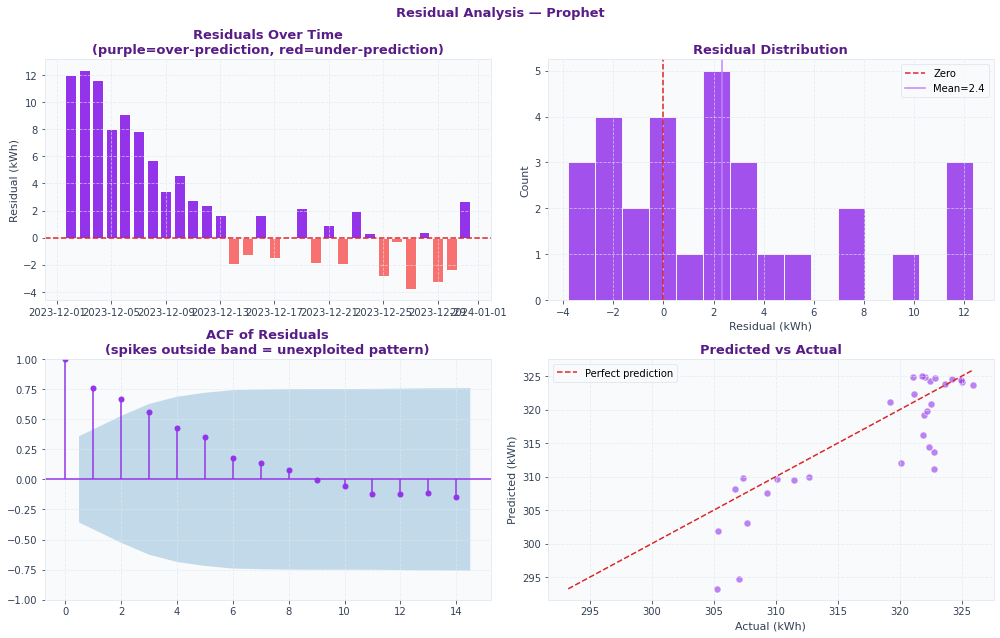

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Residual analysis + Prophet component plot (if best is Prophet)
# ─────────────────────────────────────────────────────────────────────────────
residuals = yt_test - best_preds_test

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f"Residual Analysis — {best_lecture}",
             fontsize=13, fontweight="bold", color=PURPLE_D)

# Residuals over time
ax = axes[0, 0]
ax.bar(test_raw.index, residuals, color=[PURPLE if v>=0 else "#f87171" for v in residuals],
       edgecolor="white", width=0.8)
ax.axhline(0, color="#dc2626", linewidth=1.5, linestyle="--")
ax.set_ylabel("Residual (kWh)"); ax.set_title("Residuals Over Time\n(purple=over-prediction, red=under-prediction)")

# Residual distribution
ax = axes[0, 1]
ax.hist(residuals, bins=15, color=PURPLE, edgecolor="white", alpha=0.85)
ax.axvline(0,               color="#dc2626", linewidth=1.5, linestyle="--", label="Zero")
ax.axvline(residuals.mean(),color=ACCENT,   linewidth=1.5,
           label="Mean={:.1f}".format(residuals.mean()))
ax.set_xlabel("Residual (kWh)"); ax.set_ylabel("Count")
ax.set_title("Residual Distribution"); ax.legend()

# ACF of residuals
ax = axes[1, 0]
plot_acf(residuals, lags=min(20, len(residuals)//2 - 1), ax=ax,
         color=PURPLE, vlines_kwargs={"colors": PURPLE})
ax.set_title("ACF of Residuals\n(spikes outside band = unexploited pattern)")

# Predicted vs Actual scatter
ax = axes[1, 1]
ax.scatter(yt_test, best_preds_test, alpha=0.6, color=PURPLE, edgecolors="white", s=50)
lo, hi = min(yt_test.min(), best_preds_test.min()), max(yt_test.max(), best_preds_test.max())
ax.plot([lo, hi], [lo, hi], "--", color="#dc2626", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual (kWh)"); ax.set_ylabel("Predicted (kWh)")
ax.set_title("Predicted vs Actual"); ax.legend()

plt.tight_layout()
plt.show()


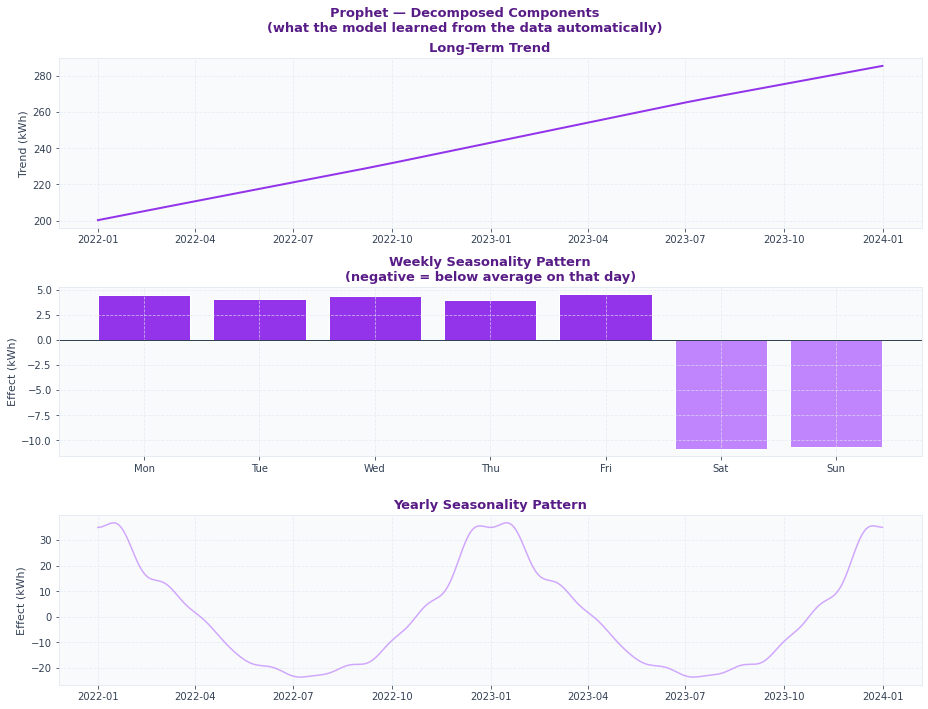

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Prophet component breakdown (only shown when Prophet is the best model) (trend + weekly + yearly seasonality)
# Shows the decomposed components that Prophet learned automatically
if best_name == "Prophet":
    # ─────────────────────────────────────────────────────────────────────────────
    # Show Prophet components regardless of best model — it is always in the lineup
    ph_full    = ph_model.make_future_dataframe(periods=len(test_raw))
    ph_comps   = ph_model.predict(ph_full)
    
    fig, axes = plt.subplots(3, 1, figsize=(13, 10))
    fig.suptitle("Prophet — Decomposed Components\n"
                 "(what the model learned from the data automatically)",
                 fontsize=13, fontweight="bold", color=PURPLE_D)
    
    # Trend
    ax = axes[0]
    ax.plot(ph_comps["ds"], ph_comps["trend"], color=PURPLE, linewidth=2)
    ax.set_ylabel("Trend (kWh)"); ax.set_title("Long-Term Trend")
    
    # Weekly seasonality
    ax = axes[1]
    days_of_week = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
    weekly = ph_comps[["ds","weekly"]].drop_duplicates("ds")
    weekly["dow"] = pd.to_datetime(weekly["ds"]).dt.dayofweek
    avg_by_dow = weekly.groupby("dow")["weekly"].mean()
    ax.bar(range(7), avg_by_dow.values, color=[PURPLE if i < 5 else ACCENT for i in range(7)],
           edgecolor="white")
    ax.set_xticks(range(7)); ax.set_xticklabels(days_of_week)
    ax.set_ylabel("Effect (kWh)"); ax.set_title("Weekly Seasonality Pattern\n(negative = below average on that day)")
    ax.axhline(0, color=SLATE, linewidth=1)
    
    # Yearly seasonality
    ax = axes[2]
    ax.plot(ph_comps["ds"], ph_comps["yearly"], color=ACCENT, linewidth=1.5, alpha=0.7)
    ax.set_ylabel("Effect (kWh)"); ax.set_title("Yearly Seasonality Pattern")
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"Prophet component plot skipped — best model is {best_name}")

> 💡 **What the components tell us:**
> - **Trend** — whether electricity consumption is growing, declining, or stable over the two years
> - **Weekly** — which days of the week have higher or lower demand; typically weekdays > weekends for commercial buildings
> - **Yearly** — seasonal effects like winter heating and summer cooling peaks

> This decomposition is similar to the STL decomposition done in the EDA, but here it's learned automatically by Prophet as part of the model fitting process.

Best model      : Prophet
Back-test RMSE  : 4.82 kWh  (estimated during back testing)
Test set  RMSE  : 5.15 kWh  (final honest result)
Test set  MAPE  : 1.19%  (goal: ≤ 5%  →  ✅ MET)
wQL P50         : 0.0119

Model                                Back-Test RMSE   Test Set RMSE
--------------------------------------------------------------------
  Back-test RMSE : 4.82 kWh (estimated during back testing)
  Test set  RMSE : 5.15 kWh (final honest result)


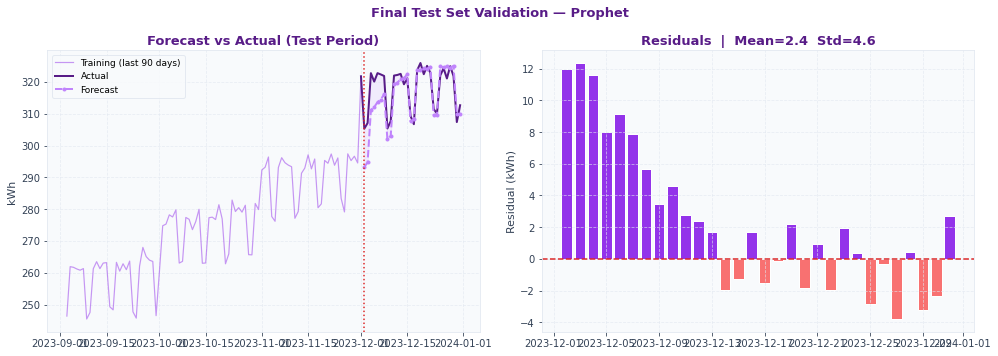

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 14 — Apply best lecture model to final test set (one honest check)
# ─────────────────────────────────────────────────────────────────────────────
# best_preds_test and yt_test were set in CELL 7
best_test_preds = best_preds_test
yt = yt_test

final_rmse = np.sqrt(mean_squared_error(yt, best_test_preds))
final_mae  = mean_absolute_error(yt, best_test_preds)
final_mape = mape(yt, best_test_preds)
final_wql  = w_quantile_loss(yt, best_test_preds)
meets_goal = final_mape <= 5.0

print(f"Best model      : {best_lecture}")
print(f"Back-test RMSE  : {results_df.loc[best_lecture, 'RMSE']:.2f} kWh  (estimated during back testing)")
print(f"Test set  RMSE  : {final_rmse:.2f} kWh  (final honest result)")
goal_str = "\u2705 MET" if meets_goal else "\u274c NOT MET"
print(f"Test set  MAPE  : {final_mape:.2f}%  (goal: \u2264 5%  \u2192  {goal_str})")
print(f"wQL P50         : {final_wql:.4f}")

# Compare back-test estimate vs test set result for all models
print(f"\n{'Model':<35} {'Back-Test RMSE':>15} {'Test Set RMSE':>15}")
print("-" * 68)
# Show back-test RMSE vs test-set RMSE for the winning model only
print(f"  Back-test RMSE : {results_df.loc[best_name, 'RMSE']:.2f} kWh (estimated during back testing)")
print(f"  Test set  RMSE : {np.sqrt(mean_squared_error(yt, best_test_preds)):.2f} kWh (final honest result)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Final Test Set Validation — {best_lecture}",
             fontsize=13, fontweight="bold", color=PURPLE_D)

# Forecast vs actual
ax = axes[0]
ctx = train_raw.iloc[-90:]
ax.plot(ctx.index, ctx.values, color=PURPLE, linewidth=1.2,
        alpha=0.5, label="Training (last 90 days)")
# Connect training line to actual: prepend last training point
bridge_idx = [ctx.index[-1]] + list(test_raw.index)
bridge_yt  = [ctx.values[-1]] + list(yt)
ax.plot(bridge_idx, bridge_yt, color=PURPLE_D, linewidth=2, label="Actual")
ax.plot(test_raw.index, best_test_preds, color=ACCENT, linewidth=2,
        linestyle="--", marker="o", markersize=3, label="Forecast")
ax.fill_between(test_raw.index, yt, best_test_preds, alpha=0.12, color=ACCENT)
ax.axvline(test_raw.index[0], color="#dc2626", linewidth=1.5, linestyle=":")
ax.set_ylabel("kWh"); ax.set_title("Forecast vs Actual (Test Period)")
ax.legend(fontsize=9)

# Residuals
ax2 = axes[1]
residuals = yt - best_test_preds
ax2.bar(test_raw.index, residuals,
        color=[PURPLE if v >= 0 else "#f87171" for v in residuals],
        edgecolor="white", width=0.8)
ax2.axhline(0, color="#dc2626", linewidth=1.5, linestyle="--")
ax2.set_ylabel("Residual (kWh)")
ax2.set_title(f"Residuals  |  Mean={residuals.mean():.1f}  Std={residuals.std():.1f}")

plt.tight_layout()
plt.show()


---

## 🔮 Section 6 — 30-Day Future Forecast with P10 / P50 / P90

> **Lecture connection (Module 4, Section 3 — wQuantileLoss):** The lecture introduces probabilistic forecasting with P10, P50, and P90 confidence bands. Here we generate all three using **Prophet**, which natively produces uncertainty intervals — exactly how Amazon Forecast presents results.

12:32:20 - cmdstanpy - INFO - Chain [1] start processing
12:32:20 - cmdstanpy - INFO - Chain [1] done processing


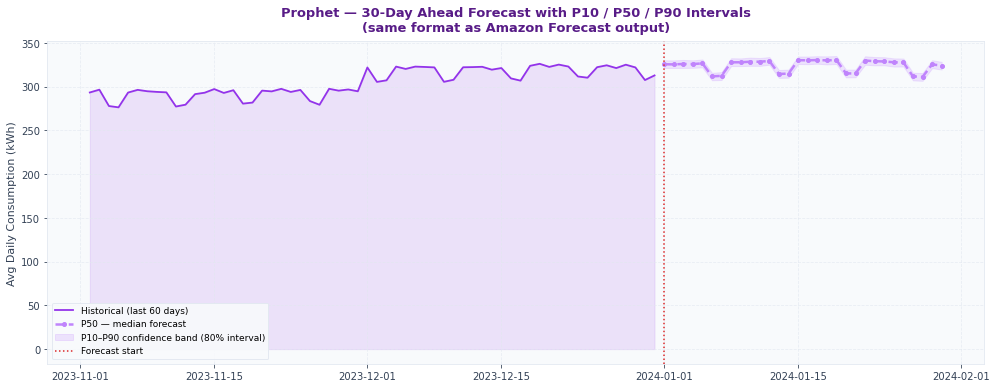


30-Day Forecast (P10 | P50 | P90):
Date                P10   P50 (forecast)      P90
--------------------------------------------------
2024-01-01        321.2            325.4    329.9
2024-01-02        321.2            325.3    329.8
2024-01-03        321.2            325.7    330.4
2024-01-04        321.3            325.6    329.9
2024-01-05        321.8            326.4    330.9
2024-01-06        307.1            311.6    315.6
2024-01-07        307.4            312.1    316.4
2024-01-08        323.4            327.6    332.3
2024-01-09        323.3            327.7    332.1
2024-01-10        323.6            328.3    333.0
2024-01-11        323.6            328.3    332.5
2024-01-12        324.9            329.2    333.6
2024-01-13        309.8            314.3    318.8
2024-01-14        310.1            314.8    319.3
2024-01-15        325.7            330.1    334.3
2024-01-16        325.5            329.9    334.2
2024-01-17        326.1            330.2    334.6
2024-01-18   

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 19 — 30-day Prophet forecast with P10 / P50 / P90 confidence intervals
# This mirrors what Amazon Forecast produces: a forecast with uncertainty bands
# ─────────────────────────────────────────────────────────────────────────────

# Refit Prophet on ALL data (train + test) for the future forecast
all_data_df = daily[[TARGET]].reset_index()
all_data_df.columns = ["ds", "y"]

ph_full_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="additive",
    interval_width=0.80    # 80% interval → approx P10 to P90
)
ph_full_model.fit(all_data_df)

# Forecast 30 days ahead
future_30 = ph_full_model.make_future_dataframe(periods=30)
fc_30     = ph_full_model.predict(future_30)
future_only = fc_30[fc_30["ds"] > daily.index.max()]

fig, ax = plt.subplots(figsize=(14, 5.5))

# Historical context (last 60 days)
ctx = daily[[TARGET]].iloc[-60:]
ax.plot(ctx.index, ctx.values, color=PURPLE, linewidth=1.8, label="Historical (last 60 days)")
ax.fill_between(ctx.index, ctx[TARGET].values, alpha=0.12, color=PURPLE)

# P50 forecast
ax.plot(pd.to_datetime(future_only["ds"]), future_only["yhat"],
        color=ACCENT, linewidth=2.5, linestyle="--", marker="o", markersize=4,
        label="P50 — median forecast")

# P10 / P90 confidence band
ax.fill_between(
    pd.to_datetime(future_only["ds"]),
    future_only["yhat_lower"],
    future_only["yhat_upper"],
    alpha=0.2, color=ACCENT,
    label="P10–P90 confidence band (80% interval)"
)

ax.axvline(pd.to_datetime(future_only["ds"].iloc[0]),
           color="#dc2626", linewidth=1.5, linestyle=":", label="Forecast start")
ax.set_ylabel("Avg Daily Consumption (kWh)")
ax.set_title("Prophet — 30-Day Ahead Forecast with P10 / P50 / P90 Intervals\n"
             "(same format as Amazon Forecast output)", pad=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\n30-Day Forecast (P10 | P50 | P90):")
print(f"{'Date':<14} {'P10':>8} {'P50 (forecast)':>16} {'P90':>8}")
print("-" * 50)
for _, row in future_only.iterrows():
    print(f"{str(row.ds.date()):<14} {row.yhat_lower:>8.1f} {row.yhat:>16.1f} {row.yhat_upper:>8.1f}")
